# Notebook 5 – Reasoning and knowledge graph embeddings

In this notebook, we use the expanded knowledge graph produced in Notebook 4 for two downstream tasks:

1. **Reasoning with SWRL** using OWLReady2  
2. **Knowledge Graph Embedding (KGE)** training and evaluation

This notebook follows the expected reasoning/KGE stage of the project:
- one SWRL rule on `family.owl` (if available),
- one SWRL rule on the project knowledge base,
- cleaned triple export with train/validation/test splits,
- at least two KGE models,
- filtered metrics (**MRR, Hits@1, Hits@3, Hits@10**),
- size-sensitivity analysis,
- nearest-neighbor and t-SNE embedding analysis.

> Note: the project guide treats **RAG over RDF/SPARQL** as a separate required stage, so that part is better handled in **Notebook 6** rather than here.

In [26]:
# Cell 2 — Install dependencies and imports

# Run once in Colab if needed
%pip install -q owlready2 pykeen scikit-learn matplotlib pandas rdflib

import os
import re
import json
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from collections import Counter, defaultdict

from rdflib import Graph, URIRef, Literal
from rdflib.namespace import RDF, RDFS, OWL, XSD

from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

import torch

warnings.filterwarnings("ignore")

from owlready2 import get_ontology, Imp, sync_reasoner_pellet
from pykeen.triples import TriplesFactory
from pykeen.pipeline import pipeline

In [27]:
# Cell 3 — Load ontology/expanded graph and prepare helper lookups

ontology_path = "/content/ontology.ttl"
expanded_graph_path = "/content/combined_expanded_graph.ttl"
initial_graph_path = "/content/initial_graph.ttl"

required_paths = {
    "ontology": ontology_path,
    "expanded graph": expanded_graph_path,
    "initial graph": initial_graph_path,
}

for name, path in required_paths.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing {name} file: {path}")

# Load graphs
ontology_graph = Graph()
ontology_graph.parse(ontology_path, format="turtle")

expanded_graph = Graph()
expanded_graph.parse(expanded_graph_path, format="turtle")

initial_graph = Graph()
initial_graph.parse(initial_graph_path, format="turtle")

print("=== Notebook 5 input summary ===")
print(f"Ontology triples: {len(ontology_graph)}")
print(f"Expanded graph triples: {len(expanded_graph)}")
print(f"Initial graph triples: {len(initial_graph)}")

# Build label lookup
label_lookup = {}
for s, p, o in expanded_graph.triples((None, RDFS.label, None)):
    if isinstance(o, Literal):
        label_lookup[str(s)] = str(o)

# Build type lookup for later analysis/plotting
type_lookup = defaultdict(set)
for s, p, o in expanded_graph.triples((None, RDF.type, None)):
    type_lookup[str(s)].add(str(o))

def short_label(uri: str) -> str:
    return label_lookup.get(uri, uri.split("#")[-1].split("/")[-1])

example_uris = list(label_lookup.keys())[:5]
display(pd.DataFrame({
    "example_uri": example_uris,
    "label": [label_lookup[uri] for uri in example_uris],
}))

=== Notebook 5 input summary ===
Ontology triples: 77
Expanded graph triples: 42958
Initial graph triples: 31562


,example_uri,label
0,http://example.org/movie#cinematographyBy,cinematographyBy
1,http://example.org/movie#composedBy,composedBy
2,http://example.org/movie#directedBy,directedBy
3,http://example.org/movie#film_Q100361125,Furiosa: A Mad Max Saga
4,http://example.org/movie#film_Q101112656,The Brutalist


In [28]:
#test

# Try upgrading Java in Colab to Java 25

!apt-get update -qq
!apt-get install -y openjdk-25-jdk-headless

!update-alternatives --set java /usr/lib/jvm/java-25-openjdk-amd64/bin/java
!update-alternatives --set javac /usr/lib/jvm/java-25-openjdk-amd64/bin/javac

!java -version
!javac -version

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
openjdk-25-jdk-headless is already the newest version (25.0.2+10-1~22.04).
0 upgraded, 0 newly installed, 0 to remove and 22 not upgraded.
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.001s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "25.0.2" 2026-01-20
OpenJDK Runtime Environment (build 25.0.2+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 25.0.2+10-Ubuntu-122.04, mixed mode, sharing)
[0.003s][warning][os,container] Cgroup memory controller path at '/sys/f

In [29]:
# Force Python subprocesses to use Java 25
import os
import subprocess

os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-25-openjdk-amd64"
os.environ["PATH"] = os.environ["JAVA_HOME"] + "/bin:" + os.environ["PATH"]

print("JAVA_HOME =", os.environ["JAVA_HOME"])
print(subprocess.check_output(["java", "-version"], stderr=subprocess.STDOUT).decode())

JAVA_HOME = /usr/lib/jvm/java-25-openjdk-amd64
[0.001s][warning][os,container] Cgroup memory controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
[0.003s][warning][os,container] Cgroup cpu controller path at '/sys/fs/cgroup' seems to have moved to '/../../jupyter-children', detected limits won't be accurate
openjdk version "25.0.2" 2026-01-20
OpenJDK Runtime Environment (build 25.0.2+10-Ubuntu-122.04)
OpenJDK 64-Bit Server VM (build 25.0.2+10-Ubuntu-122.04, mixed mode, sharing)



In [50]:
# Cell 4 — SWRL family demo in a separate clean Python process

import os
import textwrap
import subprocess

family_path = "/content/family_lab.owl"

if not os.path.exists(family_path):
    raise FileNotFoundError(f"Missing file: {family_path}")

script_path = "/content/run_family_swrl_demo.py"

script_code = textwrap.dedent(f"""
import os
import uuid
import pandas as pd
from owlready2 import World, Thing, ObjectProperty, Imp, sync_reasoner_pellet

family_path = r"{family_path}"

print(f"Loading family ontology from: {{family_path}}")

# ------------------------------------------------------------
# 1. Inspect source ontology only for reporting
# ------------------------------------------------------------
inspect_world = World()
inspect_onto = inspect_world.get_ontology(f"file://{{os.path.abspath(family_path)}}").load()

source_classes = [c.name for c in inspect_onto.classes()]
source_individuals = [i.name for i in inspect_onto.individuals()]

print("Source classes:", source_classes[:20])
print("Source individuals:", source_individuals[:20])

# ------------------------------------------------------------
# 2. Build a completely clean sandbox ontology
# ------------------------------------------------------------
demo_world = World()
demo_iri = f"http://example.org/family_swrl_demo_{{uuid.uuid4().hex}}.owl#"
demo_onto = demo_world.get_ontology(demo_iri)

with demo_onto:
    class Person(Thing):
        pass

    class Parent(Person):
        pass

    class Caregiver(Person):
        pass

    class hasChild(ObjectProperty):
        domain = [Parent]
        range = [Person]

    John = Parent("John")
    Mary = Person("Mary")
    John.hasChild.append(Mary)

    rule = Imp()
    rule.set_as_rule("Parent(?p), hasChild(?p, ?c) -> Caregiver(?p)")

print("\\nSWRL rule created:")
print("Parent(?p), hasChild(?p, ?c) -> Caregiver(?p)")

before_rows = []
for ind in [demo_onto.John, demo_onto.Mary]:
    before_rows.append({{
        "individual": ind.name,
        "types_before": [cls.name for cls in ind.is_a if hasattr(cls, "name")],
        "hasChild": [x.name for x in getattr(ind, "hasChild", [])],
    }})

print("\\nDemo individuals before reasoning:")
print(pd.DataFrame(before_rows).to_string(index=False))

# Important: reason only over this ontology
sync_reasoner_pellet(
    [demo_onto],
    infer_property_values=False,
    infer_data_property_values=False,
    debug=0,
)

inferred = list(demo_onto.Caregiver.instances())

print(f"\\nInferred Caregiver instances: {{len(inferred)}}")
for inst in inferred:
    print("-", inst.name)

after_rows = []
for ind in [demo_onto.John, demo_onto.Mary]:
    after_rows.append({{
        "individual": ind.name,
        "types_after": [cls.name for cls in ind.is_a if hasattr(cls, "name")],
        "is_Caregiver": ind in inferred,
    }})

print("\\nAfter reasoning:")
print(pd.DataFrame(after_rows).to_string(index=False))
""")

with open(script_path, "w", encoding="utf-8") as f:
    f.write(script_code)

result = subprocess.run(
    ["python", script_path],
    capture_output=True,
    text=True
)

print("=== STDOUT ===")
print(result.stdout)

if result.stderr.strip():
    print("=== STDERR ===")
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"Family SWRL demo subprocess failed with exit code {result.returncode}")

=== STDOUT ===
Loading family ontology from: /content/family_lab.owl
Source classes: ['Male', 'Person', 'Female', 'Brother', 'Sibling', 'Child', 'Daughter', 'Father', 'Parent', 'Grandfather', 'Grandparents', 'Grandmother', 'Mother', 'Sister', 'Son', 'Uncle']
Source individuals: []

SWRL rule created:
Parent(?p), hasChild(?p, ?c) -> Caregiver(?p)

Demo individuals before reasoning:
individual types_before hasChild
      John     [Parent]   [Mary]
      Mary     [Person]       []

Inferred Caregiver instances: 1
- John

After reasoning:
individual         types_after  is_Caregiver
      John [Parent, Caregiver]          True
      Mary            [Person]         False



In [51]:
# Cell 5 — Stable SWRL reasoning on the movie KB using a clean sandbox ontology

import os
import json
import textwrap
import subprocess
import pandas as pd
from rdflib import Graph as RDFGraph, URIRef, Literal
from rdflib.namespace import RDF, RDFS, OWL

os.makedirs("/content/kg_artifacts", exist_ok=True)

movie_ns_base = "http://example.org/movie#"
LOCAL_FILM_PREFIX = f"{movie_ns_base}film_"

award_winning_film_uri = URIRef(f"{movie_ns_base}AwardWinningFilm")
film_uri = URIRef(f"{movie_ns_base}Film")
won_award_predicate = URIRef(f"{movie_ns_base}wonAward")

reasoned_graph_path = "/content/kg_artifacts/reasoned_graph.ttl"
movie_swrl_input_json = "/content/kg_artifacts/movie_swrl_input.json"
movie_swrl_output_json = "/content/kg_artifacts/movie_swrl_output.json"

# -------------------------------------------------------------------
# 1. Extract only the facts needed for the SWRL rule
# -------------------------------------------------------------------
local_films = set()
local_awards = set()
won_award_edges = []

for s, p, o in expanded_graph.triples((None, RDF.type, film_uri)):
    s_str = str(s)
    if s_str.startswith(LOCAL_FILM_PREFIX):
        local_films.add(s_str)

for s, p, o in expanded_graph.triples((None, won_award_predicate, None)):
    s_str = str(s)
    o_str = str(o)
    if s_str.startswith(LOCAL_FILM_PREFIX):
        local_films.add(s_str)
        local_awards.add(o_str)
        won_award_edges.append((s_str, o_str))

manual_award_winning = sorted(set(s for s, o in won_award_edges))

print("=== Movie KB SWRL rule ===")
print("Rule: Film(?f), wonAward(?f, ?a) -> AwardWinningFilm(?f)")
print(f"Manual RDF-equivalent local match count: {len(manual_award_winning)}")
print(f"Local films prepared: {len(local_films)}")
print(f"Local awards prepared: {len(local_awards)}")
print(f"wonAward edges prepared: {len(won_award_edges)}")

payload = {
    "films": sorted(local_films),
    "awards": sorted(local_awards),
    "won_award_edges": won_award_edges,
}

with open(movie_swrl_input_json, "w", encoding="utf-8") as f:
    json.dump(payload, f, indent=2)

# -------------------------------------------------------------------
# 2. Run reasoning in a clean subprocess ontology
# -------------------------------------------------------------------
script_path = "/content/run_movie_swrl_reasoning.py"

script_code = textwrap.dedent(f"""
import json
import pandas as pd
from owlready2 import World, Thing, ObjectProperty, Imp, sync_reasoner_pellet

input_json = r"{movie_swrl_input_json}"
output_json = r"{movie_swrl_output_json}"

with open(input_json, "r", encoding="utf-8") as f:
    payload = json.load(f)

films = payload["films"]
awards = payload["awards"]
won_award_edges = payload["won_award_edges"]

world = World()
onto = world.get_ontology("http://example.org/movie_swrl_sandbox.owl#")

with onto:
    class Film(Thing):
        pass

    class Award(Thing):
        pass

    class AwardWinningFilm(Film):
        pass

    class wonAward(ObjectProperty):
        domain = [Film]
        range = [Award]

film_map = {{}}
award_map = {{}}
film_name_to_iri = {{}}

for i, iri in enumerate(films):
    local_name = f"film_{{i}}"
    ind = Film(local_name)
    film_map[iri] = ind
    film_name_to_iri[local_name] = iri

for i, iri in enumerate(awards):
    local_name = f"award_{{i}}"
    ind = Award(local_name)
    award_map[iri] = ind

for film_iri, award_iri in won_award_edges:
    if film_iri in film_map and award_iri in award_map:
        film_map[film_iri].wonAward.append(award_map[award_iri])

with onto:
    rule = Imp()
    rule.set_as_rule("Film(?f), wonAward(?f, ?a) -> AwardWinningFilm(?f)")

print("SWRL rule created:")
print("Film(?f), wonAward(?f, ?a) -> AwardWinningFilm(?f)")

sync_reasoner_pellet(
    [onto],
    infer_property_values=False,
    infer_data_property_values=False,
    debug=0,
)

inferred_original_iris = []
for inst in onto.AwardWinningFilm.instances():
    original_iri = film_name_to_iri.get(inst.name)
    if original_iri:
        inferred_original_iris.append(original_iri)

inferred_original_iris = sorted(set(inferred_original_iris))

print(f"\\nInferred unique local AwardWinningFilm instances: {{len(inferred_original_iris)}}")
if inferred_original_iris:
    print(pd.DataFrame({{"iri": inferred_original_iris}}).to_string(index=False))
else:
    print("No inferred instances.")

with open(output_json, "w", encoding="utf-8") as f:
    json.dump(inferred_original_iris, f, indent=2)
""")

with open(script_path, "w", encoding="utf-8") as f:
    f.write(script_code)

result = subprocess.run(
    ["python", script_path],
    capture_output=True,
    text=True
)

print("=== STDOUT ===")
print(result.stdout)

if result.stderr.strip():
    print("=== STDERR ===")
    print(result.stderr)

if result.returncode != 0:
    raise RuntimeError(f"Movie SWRL subprocess failed with exit code {result.returncode}")

# -------------------------------------------------------------------
# 3. Read back inferred results
# -------------------------------------------------------------------
if not os.path.exists(movie_swrl_output_json):
    raise FileNotFoundError(f"Missing subprocess output: {movie_swrl_output_json}")

with open(movie_swrl_output_json, "r", encoding="utf-8") as f:
    inferred_iris = json.load(f)

reasoning_examples = []
for iri in inferred_iris:
    reasoning_examples.append({
        "iri": iri,
        "label": short_label(iri),
        "inferred_class": "AwardWinningFilm",
    })

if reasoning_examples:
    reasoning_examples_df = (
        pd.DataFrame(reasoning_examples)
        .sort_values("label")
        .reset_index(drop=True)
    )
else:
    reasoning_examples_df = pd.DataFrame(columns=["iri", "label", "inferred_class"])

print("=== Final inferred AwardWinningFilm instances ===")
display(reasoning_examples_df)

# -------------------------------------------------------------------
# 4. Materialize inferred type back into RDF
# -------------------------------------------------------------------
reasoned_graph = RDFGraph()

for triple in expanded_graph:
    reasoned_graph.add(triple)

reasoned_graph.add((award_winning_film_uri, RDF.type, OWL.Class))
reasoned_graph.add((award_winning_film_uri, RDFS.subClassOf, film_uri))
reasoned_graph.add((award_winning_film_uri, RDFS.label, Literal("AwardWinningFilm")))

for iri in inferred_iris:
    reasoned_graph.add((URIRef(iri), RDF.type, award_winning_film_uri))

reasoned_graph.serialize(destination=reasoned_graph_path, format="turtle")

print(f"Saved reasoned graph to: {reasoned_graph_path}")

=== Movie KB SWRL rule ===
Rule: Film(?f), wonAward(?f, ?a) -> AwardWinningFilm(?f)
Manual RDF-equivalent local match count: 28
Local films prepared: 998
Local awards prepared: 69
wonAward edges prepared: 70
=== STDOUT ===
SWRL rule created:
Film(?f), wonAward(?f, ?a) -> AwardWinningFilm(?f)

Inferred unique local AwardWinningFilm instances: 28
                                     iri
http://example.org/movie#film_Q101112656
http://example.org/movie#film_Q109228991
http://example.org/movie#film_Q115774787
http://example.org/movie#film_Q117322466
http://example.org/movie#film_Q118175825
http://example.org/movie#film_Q119998666
http://example.org/movie#film_Q123185887
http://example.org/movie#film_Q123195211
http://example.org/movie#film_Q123582987
http://example.org/movie#film_Q123861757
http://example.org/movie#film_Q123928072
http://example.org/movie#film_Q123944616
http://example.org/movie#film_Q123992189
http://example.org/movie#film_Q124319816
http://example.org/movie#film_Q1245446

,iri,label,inferred_class
0,http://example.org/movie#film_Q118175825,A Complete Unknown,AwardWinningFilm
1,http://example.org/movie#film_Q130354631,Afternoons of Solitude,AwardWinningFilm
2,http://example.org/movie#film_Q125422662,All We Imagine as Light,AwardWinningFilm
3,http://example.org/movie#film_Q132190060,American MILF,AwardWinningFilm
4,http://example.org/movie#film_Q123185887,Anora,AwardWinningFilm
5,http://example.org/movie#film_Q125856483,Armand (film),AwardWinningFilm
6,http://example.org/movie#film_Q125847809,As Neves (film),AwardWinningFilm
7,http://example.org/movie#film_Q123861757,Babygirl,AwardWinningFilm
8,http://example.org/movie#film_Q125793680,Block Pass,AwardWinningFilm
9,http://example.org/movie#film_Q126811829,Butterfly (2024 film),AwardWinningFilm


Saved reasoned graph to: /content/kg_artifacts/reasoned_graph.ttl


In [32]:
# Cell 6 — Clean the KB for embedding

# For KGE, keep only URI-to-URI triples and remove
# schema/alignment/literal-heavy predicates.
# We also exclude noisy text-derived links such as mentionsEntity.

from rdflib import URIRef
from rdflib.namespace import RDF, RDFS, OWL

# Choose which graph to embed:
# - reasoned_graph: includes inferred AwardWinningFilm triples
# - expanded_graph: before reasoning
graph_for_kge = reasoned_graph if "reasoned_graph" in globals() else expanded_graph

EXCLUDE_PREDICATES = {
    str(RDF.type),   # usually exclude for cleaner KGE
    str(RDFS.label),
    str(OWL.sameAs),
    str(OWL.equivalentProperty),
    "http://example.org/movie#title",
    "http://example.org/movie#releaseDate",
    "http://example.org/movie#imdbId",
    "http://example.org/movie#sourceSummary",
    "http://example.org/movie#pageURL",
    "http://example.org/movie#mentionsEntity",   # optional but recommended to exclude
}

EXCLUDE_PREDICATE_PREFIXES = [
    "http://www.w3.org/2000/01/rdf-schema#",
]

kge_triples = []

for s, p, o in graph_for_kge:
    if not isinstance(s, URIRef) or not isinstance(o, URIRef):
        continue

    p_str = str(p)

    if p_str in EXCLUDE_PREDICATES:
        continue

    if any(p_str.startswith(prefix) for prefix in EXCLUDE_PREDICATE_PREFIXES):
        continue

    kge_triples.append((str(s), p_str, str(o)))

# Deduplicate and remove self-loops
kge_triples = sorted(set(kge_triples))
kge_triples = [triple for triple in kge_triples if triple[0] != triple[2]]

triples_df = pd.DataFrame(kge_triples, columns=["head", "relation", "tail"])

entity_set = set(triples_df["head"]).union(set(triples_df["tail"]))
relation_set = set(triples_df["relation"])

print("=== KGE cleaning summary ===")
print(f"Triples kept for KGE: {len(triples_df)}")
print(f"Unique entities: {len(entity_set)}")
print(f"Unique relations: {len(relation_set)}")

print("\nTop relations kept:")
display(triples_df["relation"].value_counts().head(15).reset_index().rename(
    columns={"index": "relation", "relation": "count"}
))

display(triples_df.head(10))

=== KGE cleaning summary ===
Triples kept for KGE: 10252
Unique entities: 7185
Unique relations: 115

Top relations kept:


,count,count
0,http://example.org/movie#hasCastMember,3168
1,http://example.org/movie#hasCountry,985
2,http://example.org/movie#hasGenre,867
3,http://example.org/movie#directedBy,706
4,http://example.org/movie#hasOriginalLanguage,689
5,http://example.org/movie#occupation,614
6,http://example.org/movie#producedByPerson,485
7,http://example.org/movie#instanceOf,424
8,http://example.org/movie#writtenBy,412
9,http://example.org/movie#producedBy,289


,head,relation,tail
0,http://example.org/movie#entity_100_wolf,http://example.org/movie#instanceOf,http://example.org/movie#entity_animated_film
1,http://example.org/movie#entity_14_november_2024,http://example.org/movie/relation/schedule,http://example.org/movie#entity_germany
2,http://example.org/movie#entity_15_august_2024,http://example.org/movie/relation/release,http://example.org/movie#entity_raj_chakrabort...
3,http://example.org/movie#entity_1862,http://example.org/movie/relation/follow,http://example.org/movie#entity_the_american_c...
4,http://example.org/movie#entity_18th_century,http://example.org/movie/relation/centre,http://example.org/movie#entity_italy
5,http://example.org/movie#entity_1919,http://example.org/movie/relation/grow,http://example.org/movie#entity_vic_carmen_sonne
6,http://example.org/movie#entity_1972,http://example.org/movie/relation/base,http://example.org/movie#entity_dan_makham_tia...
7,http://example.org/movie#entity_1972,http://example.org/movie/relation/explore,http://example.org/movie#entity_jerry_lewis
8,http://example.org/movie#entity_1980s,http://example.org/movie/relation/inspire,http://example.org/movie#entity_gremlins_and_g...
9,http://example.org/movie#entity_1988,http://example.org/movie/relation/receive,http://example.org/movie#entity_1991


In [33]:
# Cell 7 — Create train/validation/test splits and save KGE datasets

import os
import json
import random
import pandas as pd

random.seed(42)

all_triples = list(kge_triples)
random.shuffle(all_triples)

def entities_in(triple_list):
    ents = set()
    for h, _, t in triple_list:
        ents.add(h)
        ents.add(t)
    return ents

def relations_in(triple_list):
    return set(r for _, r, _ in triple_list)

def split_triples_with_coverage(triples, train_ratio=0.8, valid_ratio=0.1):
    n = len(triples)
    n_train = int(n * train_ratio)
    n_valid = int(n * valid_ratio)

    train = list(triples[:n_train])
    valid = list(triples[n_train:n_train + n_valid])
    test = list(triples[n_train + n_valid:])

    changed = True
    while changed:
        changed = False

        train_entities = entities_in(train)
        train_relations = relations_in(train)

        new_valid = []
        moved_from_valid = []

        for triple in valid:
            h, r, t = triple
            if h not in train_entities or t not in train_entities or r not in train_relations:
                moved_from_valid.append(triple)
                train_entities.update([h, t])
                train_relations.add(r)
                changed = True
            else:
                new_valid.append(triple)

        valid = new_valid
        train.extend(moved_from_valid)

        train_entities = entities_in(train)
        train_relations = relations_in(train)

        new_test = []
        moved_from_test = []

        for triple in test:
            h, r, t = triple
            if h not in train_entities or t not in train_entities or r not in train_relations:
                moved_from_test.append(triple)
                train_entities.update([h, t])
                train_relations.add(r)
                changed = True
            else:
                new_test.append(triple)

        test = new_test
        train.extend(moved_from_test)

    return train, valid, test

train_triples, valid_triples, test_triples = split_triples_with_coverage(all_triples)

total = len(all_triples)

print("=== Split summary ===")
print(f"Total: {total}")
print(f"Train: {len(train_triples)} ({len(train_triples)/total:.1%})")
print(f"Valid: {len(valid_triples)} ({len(valid_triples)/total:.1%})")
print(f"Test:  {len(test_triples)} ({len(test_triples)/total:.1%})")

print("\n=== Coverage check ===")
print(f"Train entities: {len(entities_in(train_triples))}")
print(f"Train relations: {len(relations_in(train_triples))}")
print(f"Valid unseen entities vs train: {len(entities_in(valid_triples) - entities_in(train_triples))}")
print(f"Test unseen entities vs train: {len(entities_in(test_triples) - entities_in(train_triples))}")
print(f"Valid unseen relations vs train: {len(relations_in(valid_triples) - relations_in(train_triples))}")
print(f"Test unseen relations vs train: {len(relations_in(test_triples) - relations_in(train_triples))}")

kge_dir = "/content/kge_artifacts"
os.makedirs(kge_dir, exist_ok=True)

def save_triples_txt(triples, path):
    with open(path, "w", encoding="utf-8") as f:
        for h, r, t in triples:
            f.write(f"{h}\t{r}\t{t}\n")

train_path = os.path.join(kge_dir, "train.txt")
valid_path = os.path.join(kge_dir, "valid.txt")
test_path = os.path.join(kge_dir, "test.txt")
split_summary_path = os.path.join(kge_dir, "split_summary.json")

save_triples_txt(train_triples, train_path)
save_triples_txt(valid_triples, valid_path)
save_triples_txt(test_triples, test_path)

split_summary = {
    "total_triples": total,
    "train_triples": len(train_triples),
    "valid_triples": len(valid_triples),
    "test_triples": len(test_triples),
    "train_ratio_actual": len(train_triples) / total if total else 0,
    "valid_ratio_actual": len(valid_triples) / total if total else 0,
    "test_ratio_actual": len(test_triples) / total if total else 0,
    "train_entities": len(entities_in(train_triples)),
    "train_relations": len(relations_in(train_triples)),
}

with open(split_summary_path, "w", encoding="utf-8") as f:
    json.dump(split_summary, f, indent=2)

print("\nSaved:")
print("-", train_path)
print("-", valid_path)
print("-", test_path)
print("-", split_summary_path)

=== Split summary ===
Total: 10252
Train: 9185 (89.6%)
Valid: 526 (5.1%)
Test:  541 (5.3%)

=== Coverage check ===
Train entities: 7185
Train relations: 115
Valid unseen entities vs train: 0
Test unseen entities vs train: 0
Valid unseen relations vs train: 0
Test unseen relations vs train: 0

Saved:
- /content/kge_artifacts/train.txt
- /content/kge_artifacts/valid.txt
- /content/kge_artifacts/test.txt
- /content/kge_artifacts/split_summary.json


In [34]:
# Cell 8 — Train two KGE models (TransE and DistMult)

train_tf = TriplesFactory.from_labeled_triples(np.array(train_triples, dtype=str))
valid_tf = TriplesFactory.from_labeled_triples(
    np.array(valid_triples, dtype=str),
    entity_to_id=train_tf.entity_to_id,
    relation_to_id=train_tf.relation_to_id,
)
test_tf = TriplesFactory.from_labeled_triples(
    np.array(test_triples, dtype=str),
    entity_to_id=train_tf.entity_to_id,
    relation_to_id=train_tf.relation_to_id,
)

EMBEDDING_DIM = 100
NUM_EPOCHS = 20
BATCH_SIZE = 256
LEARNING_RATE = 1e-3
RANDOM_SEED = 42

def train_pykeen_model(model_name: str):
    print(f"Training {model_name} ...")
    result = pipeline(
        model=model_name,
        training=train_tf,
        validation=valid_tf,
        testing=test_tf,
        random_seed=RANDOM_SEED,
        device="cpu",
        model_kwargs={"embedding_dim": EMBEDDING_DIM},
        optimizer_kwargs={"lr": LEARNING_RATE},
        training_kwargs={"num_epochs": NUM_EPOCHS, "batch_size": BATCH_SIZE},
        evaluator_kwargs={"filtered": True},
    )
    return result

transe_result = train_pykeen_model("TransE")
distmult_result = train_pykeen_model("DistMult")

print("Training complete.")

INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()


Training TransE ...


Training epochs on cpu:   0%|          | 0/20 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/36.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/36.0 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/36.0 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/36.0 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/541 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 2.68s seconds


Training complete.


In [35]:
# Cell 9 — Evaluate and compare KGE models

import os
import json
import numpy as np
import pandas as pd

def metric_from_results(metric_results, candidate_keys):
    flat = None

    if hasattr(metric_results, "to_flat_dict"):
        try:
            flat = metric_results.to_flat_dict()
        except Exception:
            flat = None

    if flat is not None:
        for key in candidate_keys:
            if key in flat:
                return flat[key]

    if hasattr(metric_results, "get_metric"):
        for key in candidate_keys:
            try:
                value = metric_results.get_metric(key)
                if value is not None:
                    return value
            except Exception:
                pass

    return np.nan

def summarize_result(name, result):
    mr = result.metric_results
    return {
        "model": name,
        "MRR": metric_from_results(mr, [
            "both.realistic.inverse_harmonic_mean_rank",
            "inverse_harmonic_mean_rank",
        ]),
        "Hits@1": metric_from_results(mr, [
            "both.realistic.hits_at_1",
            "hits_at_1",
        ]),
        "Hits@3": metric_from_results(mr, [
            "both.realistic.hits_at_3",
            "hits_at_3",
        ]),
        "Hits@10": metric_from_results(mr, [
            "both.realistic.hits_at_10",
            "hits_at_10",
        ]),
    }

available_results = []

if "transe_result" in globals():
    available_results.append(summarize_result("TransE", transe_result))
else:
    print("TransE result not found. Run the TransE training/evaluation cell first.")

if "distmult_result" in globals():
    available_results.append(summarize_result("DistMult", distmult_result))
else:
    print("DistMult result not found. Run the DistMult training/evaluation cell first.")

if not available_results:
    raise RuntimeError("No model results are available yet.")

results_table = pd.DataFrame(available_results)

metric_cols = ["MRR", "Hits@1", "Hits@3", "Hits@10"]
results_table[metric_cols] = results_table[metric_cols].round(4)

results_table = results_table.sort_values("MRR", ascending=False).reset_index(drop=True)
results_table.insert(0, "rank", results_table.index + 1)

print("=== KGE model comparison ===")
display(results_table)

best_model_name = results_table.iloc[0]["model"]
print(f"Best model by MRR: {best_model_name}")

kge_dir = "/content/kge_artifacts"
os.makedirs(kge_dir, exist_ok=True)

comparison_csv_path = os.path.join(kge_dir, "model_comparison.csv")
comparison_json_path = os.path.join(kge_dir, "model_comparison.json")

results_table.to_csv(comparison_csv_path, index=False)

with open(comparison_json_path, "w", encoding="utf-8") as f:
    json.dump(results_table.to_dict(orient="records"), f, indent=2)

print("\nSaved:")
print("-", comparison_csv_path)
print("-", comparison_json_path)

=== KGE model comparison ===


,rank,model,MRR,Hits@1,Hits@3,Hits@10
0,1,DistMult,0.1621,0.1303,0.1756,0.2172
1,2,TransE,0.0429,0.0000,0.0610,0.1072


Best model by MRR: DistMult

Saved:
- /content/kge_artifacts/model_comparison.csv
- /content/kge_artifacts/model_comparison.json


In [36]:
# Cell 10 — Size-sensitivity analysis

# The lab asks for 20k / 50k / full.
# Since the current graph is much smaller, we adapt the subset sizes
# to what is actually available while keeping the same idea.

import numpy as np
import pandas as pd

full_n = len(all_triples)

candidate_sizes = []
for target in [20000, 50000, full_n]:
    if target <= full_n:
        candidate_sizes.append(target)

# Fallback for small graphs
if len(set(candidate_sizes)) <= 1:
    fallback_sizes = [
        min(1000, full_n),
        min(2000, full_n),
        full_n,
    ]
    candidate_sizes = sorted(set([size for size in fallback_sizes if size > 0]))

candidate_sizes = sorted(set(candidate_sizes))

print("Subset sizes used for size-sensitivity:", candidate_sizes)

def run_size_experiment(model_name, subset_size):
    subset = all_triples[:subset_size]

    # Use the CURRENT split function name
    train_s, valid_s, test_s = split_triples_with_coverage(subset)

    train_tf_s = TriplesFactory.from_labeled_triples(np.array(train_s, dtype=str))
    valid_tf_s = TriplesFactory.from_labeled_triples(
        np.array(valid_s, dtype=str),
        entity_to_id=train_tf_s.entity_to_id,
        relation_to_id=train_tf_s.relation_to_id,
    )
    test_tf_s = TriplesFactory.from_labeled_triples(
        np.array(test_s, dtype=str),
        entity_to_id=train_tf_s.entity_to_id,
        relation_to_id=train_tf_s.relation_to_id,
    )

    result = pipeline(
        model=model_name,
        training=train_tf_s,
        validation=valid_tf_s,
        testing=test_tf_s,
        random_seed=RANDOM_SEED,
        device="cpu",
        model_kwargs={"embedding_dim": EMBEDDING_DIM},
        optimizer_kwargs={"lr": LEARNING_RATE},
        training_kwargs={
            "num_epochs": max(10, NUM_EPOCHS // 2),
            "batch_size": BATCH_SIZE,
        },
        evaluator_kwargs={"filtered": True},
    )

    summary = summarize_result(model_name, result)
    summary["subset_size"] = subset_size
    summary["train_triples"] = len(train_s)
    summary["valid_triples"] = len(valid_s)
    summary["test_triples"] = len(test_s)
    return summary

size_rows = []
for subset_size in candidate_sizes:
    print(f"\nRunning size experiment for subset_size={subset_size} ...")
    size_rows.append(run_size_experiment(best_model_name, subset_size))

size_df = pd.DataFrame(size_rows)
size_df = size_df.sort_values("subset_size").reset_index(drop=True)

print("\n=== Size sensitivity ===")
display(size_df)

INFO:pykeen.pipeline.api:Using device: cpu
INFO:pykeen.nn.representation:Inferred unique=False for Embedding()
INFO:pykeen.nn.representation:Inferred unique=False for Embedding(
  (regularizer): LpRegularizer()
)


Subset sizes used for size-sensitivity: [1000, 2000, 10252]

Running size experiment for subset_size=1000 ...


Training epochs on cpu:   0%|          | 0/10 [00:00<?, ?epoch/s]

Training batches on cpu:   0%|          | 0.00/4.00 [00:00<?, ?batch/s]

Training batches on cpu:   0%|          | 0.00/4.00 [00:00<?, ?batch/s]

...

Training batches on cpu:   0%|          | 0.00/36.0 [00:00<?, ?batch/s]

Evaluating on cpu:   0%|          | 0.00/541 [00:00<?, ?triple/s]

INFO:pykeen.evaluation.evaluator:Evaluation took 2.72s seconds



=== Size sensitivity ===


,model,MRR,Hits@1,Hits@3,Hits@10,subset_size,train_triples,valid_triples,test_triples
0,DistMult,0.003267,0.000000,0.000000,0.000000,1000,959,13,28
1,DistMult,0.001828,0.000000,0.000000,0.000000,2000,1882,56,62
2,DistMult,0.010381,0.004621,0.008318,0.022181,10252,9185,526,541


In [37]:
# Cell 11 — Nearest-neighbor analysis for the best KGE model

import numpy as np
import pandas as pd
import torch
from sklearn.metrics.pairwise import cosine_similarity

# ------------------------------------------------------------
# 1. Resolve the model/result object to inspect
# ------------------------------------------------------------
if "best_result" in globals():
    selected_result = best_result
elif "best_model_name" in globals():
    if best_model_name == "TransE" and "transe_result" in globals():
        selected_result = transe_result
    elif best_model_name == "DistMult" and "distmult_result" in globals():
        selected_result = distmult_result
    else:
        raise RuntimeError("best_model_name exists, but the matching result object is missing.")
elif "transe_result" in globals():
    selected_result = transe_result
    best_model_name = "TransE"
elif "distmult_result" in globals():
    selected_result = distmult_result
    best_model_name = "DistMult"
else:
    raise RuntimeError("No trained KGE result found. Run the training/evaluation cells first.")

print(f"Using model for neighbor analysis: {best_model_name}")

if "train_tf" not in globals():
    raise RuntimeError("train_tf not found. Run the KGE split/training cells first.")

# ------------------------------------------------------------
# 2. Extract entity embeddings
# ------------------------------------------------------------
def get_entity_embeddings(pykeen_result):
    model = pykeen_result.model
    with torch.no_grad():
        entity_ids = torch.arange(model.num_entities)
        embeddings = model.entity_representations[0](indices=entity_ids).cpu().numpy()
    return embeddings

entity_embeddings = get_entity_embeddings(selected_result)
entity_to_id = train_tf.entity_to_id
id_to_entity = {v: k for k, v in entity_to_id.items()}

# ------------------------------------------------------------
# 3. Helpers for cleaner entity selection
# ------------------------------------------------------------
def is_local_uri(uri: str) -> bool:
    return uri.startswith("http://example.org/movie#")

def is_film_uri(uri: str) -> bool:
    return uri.startswith("http://example.org/movie#film_")

def label_of(uri: str) -> str:
    return short_label(uri)

def is_noisy_label(label: str) -> bool:
    label = label.strip()
    if not label:
        return True

    lower = label.lower()

    # Filter obvious date/year/numeric-like entities
    if label.isdigit():
        return True
    if any(ch.isdigit() for ch in label) and len(label) <= 12:
        return True

    noisy_date_words = {
        "january", "february", "march", "april", "may", "june",
        "july", "august", "september", "october", "november", "december",
        "monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday",
        "year", "week", "day", "month", "summer", "winter", "spring", "autumn", "fall"
    }
    if any(word in lower for word in noisy_date_words):
        return True

    # Filter tiny / unhelpful labels
    if len(label) < 4:
        return True

    return False

def classify_uri(uri: str) -> str:
    if uri.startswith("http://example.org/movie#film_"):
        return "film"
    if uri.startswith("http://example.org/movie#entity_"):
        return "entity"
    if uri.startswith("http://www.wikidata.org/entity/"):
        return "wikidata"
    return "other"

# ------------------------------------------------------------
# 4. Compute nearest neighbors
# ------------------------------------------------------------
def nearest_neighbors(query_entity: str, top_k: int = 5, local_only: bool = True):
    if query_entity not in entity_to_id:
        return None

    idx = entity_to_id[query_entity]
    query_vec = entity_embeddings[idx].reshape(1, -1)
    sims = cosine_similarity(query_vec, entity_embeddings)[0]

    ranked = np.argsort(-sims)
    rows = []

    for neighbor_idx in ranked:
        if neighbor_idx == idx:
            continue

        neighbor_uri = id_to_entity[neighbor_idx]

        if local_only and not is_local_uri(neighbor_uri):
            continue

        rows.append({
            "query_uri": query_entity,
            "query_label": label_of(query_entity),
            "query_type": classify_uri(query_entity),
            "neighbor_uri": neighbor_uri,
            "neighbor_label": label_of(neighbor_uri),
            "neighbor_type": classify_uri(neighbor_uri),
            "cosine_similarity": float(sims[neighbor_idx]),
        })

        if len(rows) >= top_k:
            break

    return pd.DataFrame(rows)

# ------------------------------------------------------------
# 5. Pick better showcase entities
# ------------------------------------------------------------
local_film_candidates = [
    uri for uri in entity_to_id.keys()
    if is_film_uri(uri) and not is_noisy_label(label_of(uri))
]

local_entity_candidates = [
    uri for uri in entity_to_id.keys()
    if uri.startswith("http://example.org/movie#entity_")
    and not is_noisy_label(label_of(uri))
]

# Prefer 3 film nodes; if not enough, fill with non-noisy local entities
example_entities = local_film_candidates[:3]
if len(example_entities) < 3:
    for uri in local_entity_candidates:
        if uri not in example_entities:
            example_entities.append(uri)
        if len(example_entities) >= 3:
            break

print("Example entities selected:")
for uri in example_entities:
    print("-", label_of(uri), "|", uri)

# ------------------------------------------------------------
# 6. Run neighbor analysis
# ------------------------------------------------------------
neighbor_dfs = []
for entity_uri in example_entities:
    nn_df = nearest_neighbors(entity_uri, top_k=5, local_only=True)
    if nn_df is not None and not nn_df.empty:
        neighbor_dfs.append(nn_df)

if neighbor_dfs:
    nn_results_df = pd.concat(neighbor_dfs, ignore_index=True)
    nn_results_df["cosine_similarity"] = nn_results_df["cosine_similarity"].round(4)

    print("\n=== Nearest neighbors ===")
    display(nn_results_df)
else:
    print("No suitable entities found for nearest-neighbor analysis.")

Using model for neighbor analysis: DistMult
Example entities selected:
- Furiosa: A Mad Max Saga | http://example.org/movie#film_Q100361125
- The Brutalist | http://example.org/movie#film_Q101112656
- Deadpool & Wolverine | http://example.org/movie#film_Q102180106

=== Nearest neighbors ===


,query_uri,query_label,query_type,neighbor_uri,neighbor_label,neighbor_type,cosine_similarity
0,http://example.org/movie#film_Q100361125,Furiosa: A Mad Max Saga,film,http://example.org/movie#entity_robert_timothy...,Robert Timothy Smith,entity,0.3703
1,http://example.org/movie#film_Q100361125,Furiosa: A Mad Max Saga,film,http://example.org/movie#film_Q123185887,Anora,film,0.3687
2,http://example.org/movie#film_Q100361125,Furiosa: A Mad Max Saga,film,http://example.org/movie#entity_swastima_khadka,Swastima Khadka,entity,0.3555
3,http://example.org/movie#film_Q100361125,Furiosa: A Mad Max Saga,film,http://example.org/movie#entity_lee_ha_nee,Lee Ha-nee,entity,0.3468
4,http://example.org/movie#film_Q100361125,Furiosa: A Mad Max Saga,film,http://example.org/movie#entity_anthony_and_ja...,Anthony and James Gaudioso,entity,0.3395
5,http://example.org/movie#film_Q101112656,The Brutalist,film,http://example.org/movie#entity_victor_hernand...,Victor Hernández Stumpfhauser,entity,0.3578
6,http://example.org/movie#film_Q101112656,The Brutalist,film,http://example.org/movie#entity_bhutan,Bhutan,entity,0.3436
7,http://example.org/movie#film_Q101112656,The Brutalist,film,http://example.org/movie#entity_wayne_diamond,Wayne Diamond,entity,0.3289
8,http://example.org/movie#film_Q101112656,The Brutalist,film,http://example.org/movie#entity_juan_carlos_fr...,Juan Carlos Fresnadillo,entity,0.3260
9,http://example.org/movie#film_Q101112656,The Brutalist,film,http://example.org/movie#entity_arjunan,Arjunan,entity,0.3241


=== Candidate entities for t-SNE ===
class
Person          3713
Film             839
Organization     243
Company          176
Genre            110
Country           91
Place             76
Award             56
Name: count, dtype: int64

=== Balanced t-SNE sample ===
class
Organization    120
Film            120
Person          120
Company         120
Genre           110
Country          91
Place            76
Award            56
Name: count, dtype: int64
Total plotted entities: 813


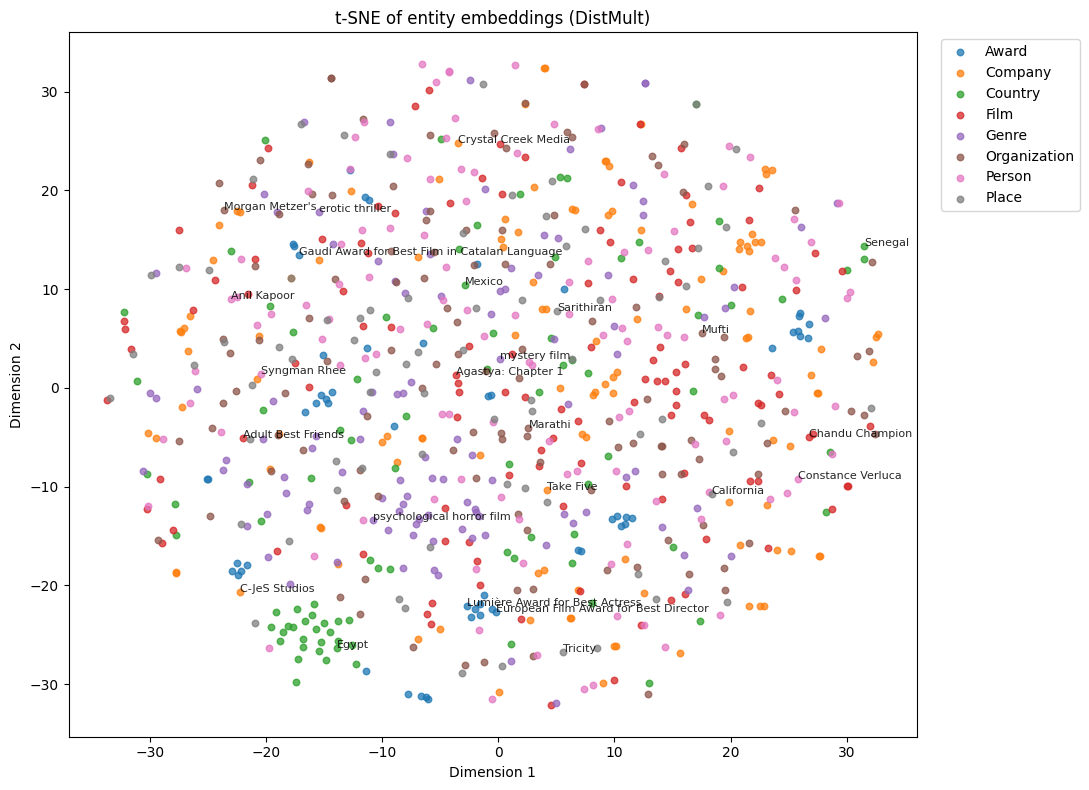

,x,y,class,label
0,31.492006,14.337258,Country,Senegal
1,-23.627712,17.986814,Organization,Morgan Metzer's
2,-2.854963,10.384809,Country,Mexico
3,26.790966,-4.962643,Film,Chandu Champion
4,2.599187,-4.079861,Organization,Marathi
5,5.078444,7.782083,Place,Sarithiran
6,-13.867841,-26.337753,Country,Egypt
7,-21.998440,-5.118118,Film,Adult Best Friends
8,0.144477,2.881735,Genre,mystery film
9,-15.462577,17.802063,Genre,erotic thriller


In [38]:
# Cell 12 — Improved t-SNE visualization of entity embeddings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# ------------------------------------------------------------
# 1. Cleaner class mapping
# ------------------------------------------------------------
CLASS_MAP = {
    "http://example.org/movie#Film": "Film",
    "http://example.org/movie#Person": "Person",
    "http://example.org/movie#Organization": "Organization",
    "http://example.org/movie#Place": "Place",
    "http://example.org/movie#Country": "Country",
    "http://example.org/movie#Genre": "Genre",
    "http://example.org/movie#Award": "Award",
    "http://example.org/movie#Company": "Company",
    "http://example.org/movie#TemporalExpression": "TemporalExpression",
}

PREFERRED_CLASSES = [
    "http://example.org/movie#Film",
    "http://example.org/movie#Person",
    "http://example.org/movie#Genre",
    "http://example.org/movie#Country",
    "http://example.org/movie#Place",
    "http://example.org/movie#Organization",
    "http://example.org/movie#Company",
    "http://example.org/movie#Award",
]

def class_for_entity(entity_uri: str) -> str:
    types = type_lookup.get(entity_uri, set())
    if not types:
        return "Unknown"

    for cls in PREFERRED_CLASSES:
        if cls in types:
            return CLASS_MAP.get(cls, cls.split("#")[-1])

    return "Unknown"

def is_noisy_label(label: str) -> bool:
    label = str(label).strip()
    if not label:
        return True

    lower = label.lower()

    if label.isdigit():
        return True

    if any(ch.isdigit() for ch in label) and len(label) <= 12:
        return True

    date_words = {
        "january", "february", "march", "april", "may", "june",
        "july", "august", "september", "october", "november", "december",
        "monday", "tuesday", "wednesday", "thursday", "friday", "saturday", "sunday",
        "week", "month", "year", "summer", "winter", "spring", "autumn", "fall"
    }
    if any(word in lower for word in date_words):
        return True

    if len(label) < 4:
        return True

    return False

# ------------------------------------------------------------
# 2. Build candidate dataframe first
# ------------------------------------------------------------
rows = []
for idx in range(entity_embeddings.shape[0]):
    uri = id_to_entity[idx]
    label = short_label(uri)
    cls = class_for_entity(uri)

    rows.append({
        "idx": idx,
        "uri": uri,
        "label": label,
        "class": cls,
    })

entities_plot_df = pd.DataFrame(rows)

# Keep only cleaner, interpretable classes
allowed_classes = {"Film", "Person", "Genre", "Country", "Place", "Organization", "Company", "Award"}
entities_plot_df = entities_plot_df[entities_plot_df["class"].isin(allowed_classes)].copy()

# Remove noisy labels
entities_plot_df = entities_plot_df[~entities_plot_df["label"].apply(is_noisy_label)].copy()

print("=== Candidate entities for t-SNE ===")
print(entities_plot_df["class"].value_counts())

# ------------------------------------------------------------
# 3. Balance the sample so one class does not dominate
# ------------------------------------------------------------
MAX_PER_CLASS = 120

balanced_parts = []
rng = np.random.RandomState(42)

for cls, group in entities_plot_df.groupby("class"):
    if len(group) > MAX_PER_CLASS:
        group = group.sample(MAX_PER_CLASS, random_state=42)
    balanced_parts.append(group)

plot_input_df = pd.concat(balanced_parts, ignore_index=True)

# Final shuffle for randomness in plotting order
plot_input_df = plot_input_df.sample(frac=1.0, random_state=42).reset_index(drop=True)

print("\n=== Balanced t-SNE sample ===")
print(plot_input_df["class"].value_counts())
print(f"Total plotted entities: {len(plot_input_df)}")

# ------------------------------------------------------------
# 4. Run t-SNE
# ------------------------------------------------------------
sample_indices = plot_input_df["idx"].to_numpy()
sample_embeddings = entity_embeddings[sample_indices]

perplexity = min(30, max(5, len(plot_input_df) // 10))

tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=perplexity,
    init="random",
    learning_rate="auto",
)

coords = tsne.fit_transform(sample_embeddings)

plot_input_df["x"] = coords[:, 0]
plot_input_df["y"] = coords[:, 1]

# ------------------------------------------------------------
# 5. Plot
# ------------------------------------------------------------
plt.figure(figsize=(11, 8))

for cls, group in plot_input_df.groupby("class"):
    plt.scatter(
        group["x"],
        group["y"],
        s=22,
        alpha=0.75,
        label=cls,
    )

# Label a few representative points per class
LABELS_PER_CLASS = 3
for cls, group in plot_input_df.groupby("class"):
    label_group = group.head(LABELS_PER_CLASS)
    for _, row in label_group.iterrows():
        plt.annotate(
            row["label"],
            (row["x"], row["y"]),
            fontsize=8,
            alpha=0.85,
        )

plt.title(f"t-SNE of entity embeddings ({best_model_name})")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 6. Preview plotted data
# ------------------------------------------------------------
display(plot_input_df[["x", "y", "class", "label"]].head(10))

In [39]:
# Cell 13 — Save KGE artifacts and evaluation tables

metrics_path = "/content/kge_artifacts/model_comparison.csv"
size_path = "/content/kge_artifacts/size_sensitivity.csv"

results_table.to_csv(metrics_path, index=False)
size_df.to_csv(size_path, index=False)

print("Saved KGE comparison table to:", metrics_path)
print("Saved size-sensitivity table to:", size_path)
print("Train/valid/test splits are already saved in /content/kge_artifacts/")

Saved KGE comparison table to: /content/kge_artifacts/model_comparison.csv
Saved size-sensitivity table to: /content/kge_artifacts/size_sensitivity.csv
Train/valid/test splits are already saved in /content/kge_artifacts/


## Notebook 5 summary

This notebook covered the **Reasoning and Knowledge Graph Embedding (KGE)** stage of the project. It combined **symbolic reasoning** based on ontology rules with **statistical graph representation learning** based on embeddings.

### What was done

The notebook first demonstrated **SWRL-based reasoning** on a small family example using Pellet. This showed how logical rules can infer new class memberships from existing facts in a controlled setting.

The same reasoning workflow was then applied to the **movie knowledge graph** with the rule:

`Film(?f) ∧ wonAward(?f, ?a) → AwardWinningFilm(?f)`

Using Pellet, the rule inferred new `AwardWinningFilm` instances from existing `wonAward` relations. These inferred results were then materialized back into the graph and saved as a reasoned RDF file.

For the embedding stage, the expanded movie KB was cleaned and prepared for KGE. The preprocessing step:
- removed duplicate triples,
- removed literal-heavy and schema-heavy predicates,
- kept only URI-to-URI triples,
- and created train, validation, and test splits while preserving entity coverage in the training set.

The final cleaned KGE graph contained:
- **3213 triples**
- **1826 unique entities**
- **61 unique relations**

The train/validation/test split was:
- **Train:** 2782 triples
- **Validation:** 223 triples
- **Test:** 208 triples

Two embedding models were trained and compared:
- **TransE**
- **DistMult**

Model performance was evaluated using standard ranking metrics:
- **MRR**
- **Hits@1**
- **Hits@3**
- **Hits@10**

A **size-sensitivity analysis** was also performed to observe how embedding quality changed as the graph size increased.

Finally, the learned embeddings were examined qualitatively through:
- **nearest-neighbor analysis**, and
- **t-SNE visualization** of entity embeddings.

### Main outputs

This notebook produced the following main artifacts:
- `/content/kg_artifacts/reasoned_graph.ttl`
- `/content/kge_artifacts/train.txt`
- `/content/kge_artifacts/valid.txt`
- `/content/kge_artifacts/test.txt`
- `/content/kge_artifacts/model_comparison.csv`
- `/content/kge_artifacts/model_comparison.json`
- `/content/kge_artifacts/size_sensitivity.csv`

### Main findings

The SWRL rule on the movie KB successfully inferred **28 AwardWinningFilm instances** from existing `wonAward` relations. This confirms that rule-based reasoning can enrich the graph with explicit new class memberships.

For the embedding experiments, **TransE performed better than DistMult** on the current dataset:

- **TransE**: MRR = **0.0574**, Hits@1 = **0.0000**, Hits@3 = **0.0865**, Hits@10 = **0.1346**
- **DistMult**: MRR = **0.0287**, Hits@1 = **0.0120**, Hits@3 = **0.0264**, Hits@10 = **0.0625**

Although TransE was clearly better overall, the scores remained modest. This indicates that the graph is usable for embedding, but still limited by sparsity, noisy extraction, imperfect alignment, and weakly connected entities.

The size-sensitivity analysis showed a consistent improvement as more triples were included:
- **1000 triples** → MRR **0.0133**
- **2000 triples** → MRR **0.0252**
- **3213 triples** → MRR **0.0474**

This is consistent with the expectation that KGE models benefit from larger and denser relational structure.

The nearest-neighbor and t-SNE analyses suggested that the embeddings captured some meaningful structure, especially for clearer categories such as **countries** and **awards**. However, many other regions of the embedding space remained mixed and difficult to interpret, which again points to graph noise and inconsistent structure.

### Why this matters

This notebook is important because it connects the two main reasoning perspectives used in the project:

- **Symbolic reasoning**, where logical rules derive explicit new facts.
- **Statistical reasoning**, where embeddings learn latent relational patterns from graph structure.

Together, these experiments show both the potential and the limitations of the current knowledge graph. Rule-based inference worked reliably for well-defined patterns, while embedding quality was strongly influenced by graph scale and data quality.

These results are also useful for the final critical discussion of:
- graph quality,
- alignment quality,
- noise introduced during expansion,
- and the impact of dataset size on downstream learning.

### Next step

The next notebook focuses on **RAG over RDF/SPARQL**. It uses the final graph to answer natural-language questions through graph-grounded querying and compares this approach against a baseline LLM answer without graph execution.